# 01 - Fundamentos de NumPy: Señales de Telemetría Vehicular

**Pregunta de negocio:** ¿Cómo afecta la frecuencia de muestreo al volumen de datos?

## Objetivos
- Dominar operaciones básicas con arrays de NumPy
- Entender distribuciones aleatorias y ruido
- Generar señales de voltaje de batería (1 Hz) y RPM motor (10 Hz)
- Calcular el impacto de la frecuencia de muestreo en el volumen de datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Estilo de gráficas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Fijamos semilla para reproducibilidad
rng = np.random.default_rng(42)

print(f"NumPy versión: {np.__version__}")

NumPy versión: 2.4.3


## 1. Arrays básicos: Creación y operaciones

Un array de NumPy es la estructura fundamental para datos numéricos en ciencia de datos.
A diferencia de las listas de Python, los arrays permiten operaciones vectorizadas (sin loops).

In [2]:
# Crear arrays de diferentes formas
zeros = np.zeros(10)
ones = np.ones(5)
rango = np.arange(0, 100, 5)
lineal = np.linspace(0, 1, 11)

print(f"zeros: {zeros}")
print(f"ones: {ones}")
print(f"rango: {rango}")
print(f"lineal: {lineal}")
print(f"\nshape de rango: {rango.shape}, dtype: {rango.dtype}")

zeros: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
ones: [1. 1. 1. 1. 1.]
rango: [ 0  5 10 15 20 25 30 35 40 45 50 55 60 65 70 75 80 85 90 95]
lineal: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]

shape de rango: (20,), dtype: int64


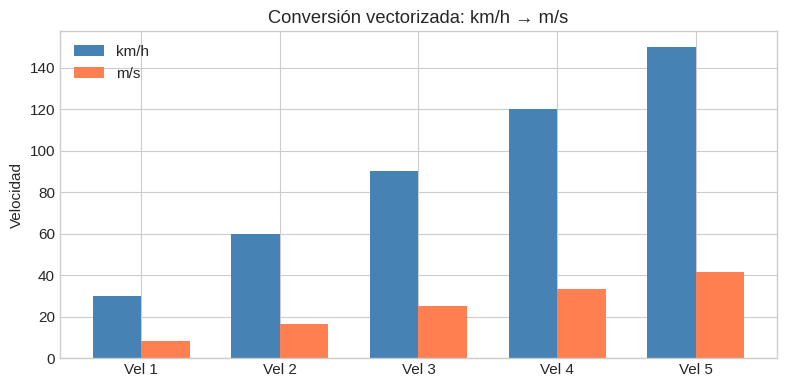

Media: 90.0 km/h
Desv. estándar: 42.4 km/h


In [3]:
# Operaciones vectorizadas: convertir km/h a m/s
velocidades_kmh = np.array([30, 60, 90, 120, 150])
velocidades_ms = velocidades_kmh / 3.6

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(velocidades_kmh))
width = 0.35
ax.bar(x - width/2, velocidades_kmh, width, label='km/h', color='steelblue')
ax.bar(x + width/2, velocidades_ms, width, label='m/s', color='coral')
ax.set_xticks(x)
ax.set_xticklabels([f'Vel {i+1}' for i in x])
ax.set_ylabel('Velocidad')
ax.set_title('Conversión vectorizada: km/h → m/s')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Media: {velocidades_kmh.mean():.1f} km/h")
print(f"Desv. estándar: {velocidades_kmh.std():.1f} km/h")

## 2. Distribuciones aleatorias: Simulando ruido de sensores

Los sensores reales no producen valores perfectos. Necesitamos entender las distribuciones
para simular ruido realista.

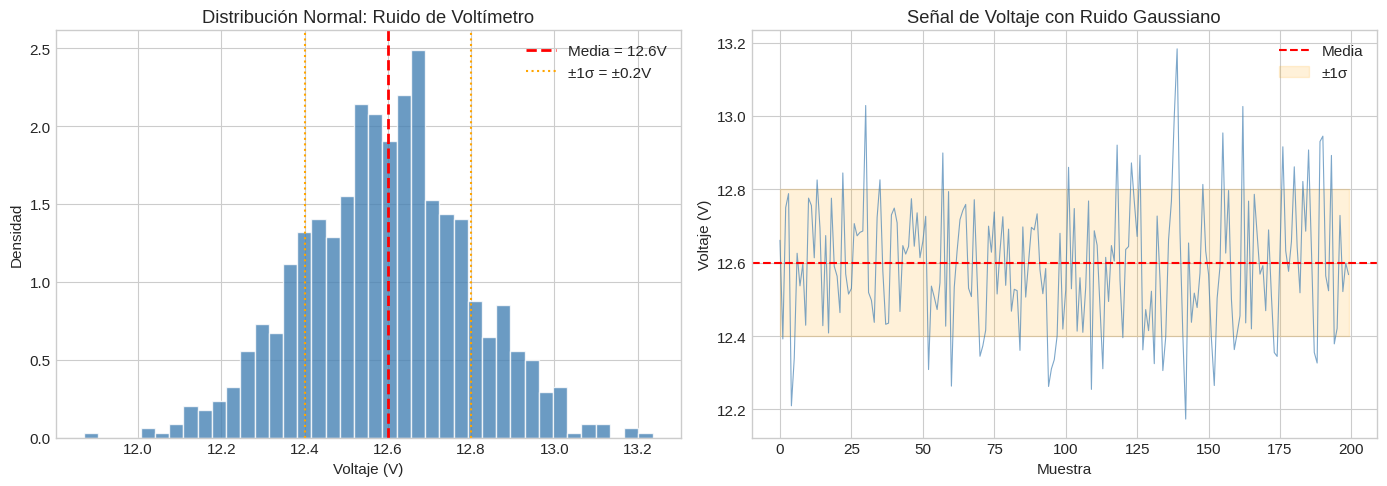

Media real: 12.5942V (esperada: 12.6V)
Std real: 0.1977V (esperada: 0.2V)


In [4]:
# Distribución Normal (Gaussiana)
voltaje_medio = 12.6
ruido_std = 0.2
n_muestras = 1000

voltajes = rng.normal(loc=voltaje_medio, scale=ruido_std, size=n_muestras)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(voltajes, bins=40, color='steelblue', edgecolor='white', alpha=0.8, density=True)
axes[0].axvline(voltaje_medio, color='red', linestyle='--', linewidth=2, label=f'Media = {voltaje_medio}V')
axes[0].axvline(voltaje_medio - ruido_std, color='orange', linestyle=':', label=f'±1σ = ±{ruido_std}V')
axes[0].axvline(voltaje_medio + ruido_std, color='orange', linestyle=':')
axes[0].set_xlabel('Voltaje (V)')
axes[0].set_ylabel('Densidad')
axes[0].set_title('Distribución Normal: Ruido de Voltímetro')
axes[0].legend()

# Serie temporal (primeras 200 muestras)
axes[1].plot(voltajes[:200], linewidth=0.8, color='steelblue', alpha=0.7)
axes[1].axhline(voltaje_medio, color='red', linestyle='--', linewidth=1.5, label='Media')
axes[1].fill_between(range(200), voltaje_medio - ruido_std, voltaje_medio + ruido_std,
                      alpha=0.15, color='orange', label='±1σ')
axes[1].set_xlabel('Muestra')
axes[1].set_ylabel('Voltaje (V)')
axes[1].set_title('Señal de Voltaje con Ruido Gaussiano')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Media real: {voltajes.mean():.4f}V (esperada: {voltaje_medio}V)")
print(f"Std real: {voltajes.std():.4f}V (esperada: {ruido_std}V)")

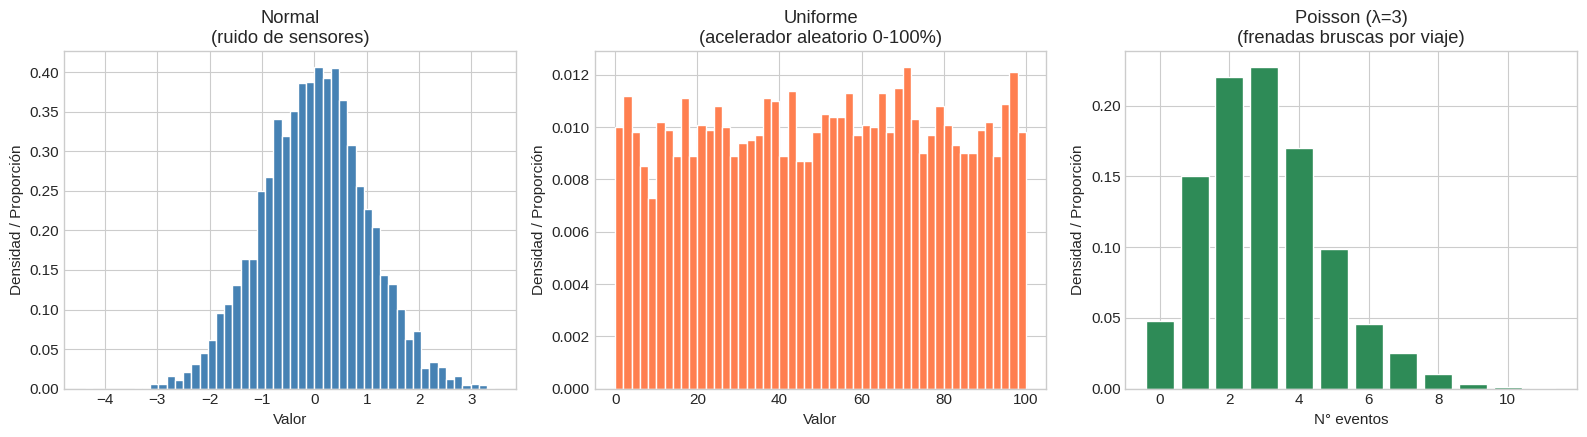

In [5]:
# Comparar 3 distribuciones relevantes para telemetría
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Normal: ruido de sensor
normal_data = rng.normal(0, 1, 5000)
axes[0].hist(normal_data, bins=50, color='steelblue', edgecolor='white', density=True)
axes[0].set_title('Normal\n(ruido de sensores)')
axes[0].set_xlabel('Valor')

# Uniforme: posición del acelerador
uniform_data = rng.uniform(0, 100, 5000)
axes[1].hist(uniform_data, bins=50, color='coral', edgecolor='white', density=True)
axes[1].set_title('Uniforme\n(acelerador aleatorio 0-100%)')
axes[1].set_xlabel('Valor')

# Poisson: eventos por viaje
poisson_data = rng.poisson(lam=3, size=5000)
values, counts = np.unique(poisson_data, return_counts=True)
axes[2].bar(values, counts / len(poisson_data), color='seagreen', edgecolor='white')
axes[2].set_title('Poisson (λ=3)\n(frenadas bruscas por viaje)')
axes[2].set_xlabel('N° eventos')

for ax in axes:
    ax.set_ylabel('Densidad / Proporción')

plt.tight_layout()
plt.show()

## 3. Ejercicio principal: Señal de voltaje de batería (1 Hz, 3600 valores)

Simularemos una hora de lecturas de voltaje de una batería de vehículo eléctrico.
El voltaje debe:
- Comenzar alto (~400V para un EV) y decrecer gradualmente (descarga)
- Tener ruido gaussiano (sensor)
- Mostrar caídas cuando hay aceleración fuerte

In [6]:
# Parámetros
duracion_segundos = 3600  # 1 hora
freq_muestreo = 1  # Hz
n_puntos = duracion_segundos * freq_muestreo

# Señal base: voltaje que decrece linealmente (descarga)
voltaje_inicial = 400  # V
voltaje_final_v = 370  # V
voltaje_base = np.linspace(voltaje_inicial, voltaje_final_v, n_puntos)

# Ruido del sensor
ruido_sensor = rng.normal(0, 1.5, n_puntos)

# Caídas de voltaje por aceleración fuerte
n_eventos = rng.integers(5, 9)
posiciones_eventos = rng.choice(range(100, n_puntos - 100), size=n_eventos, replace=False)

caidas = np.zeros(n_puntos)
for pos in posiciones_eventos:
    duracion_caida = rng.integers(20, 40)
    profundidad = rng.uniform(5, 15)
    mitad = duracion_caida // 2
    bajada = np.linspace(0, -profundidad, mitad)
    subida = np.linspace(-profundidad, 0, duracion_caida - mitad)
    evento = np.concatenate([bajada, subida])
    end = min(pos + duracion_caida, n_puntos)
    caidas[pos:end] = evento[:end - pos]

# Señal final
voltaje_final_signal = voltaje_base + ruido_sensor + caidas

print(f"Señal completa: {len(voltaje_final_signal):,} puntos")
print(f"  Media: {voltaje_final_signal.mean():.2f}V")
print(f"  Min: {voltaje_final_signal.min():.2f}V, Max: {voltaje_final_signal.max():.2f}V")
print(f"  Eventos de aceleración: {n_eventos}")

Señal completa: 3,600 puntos
  Media: 384.76V
  Min: 357.97V, Max: 403.88V
  Eventos de aceleración: 5


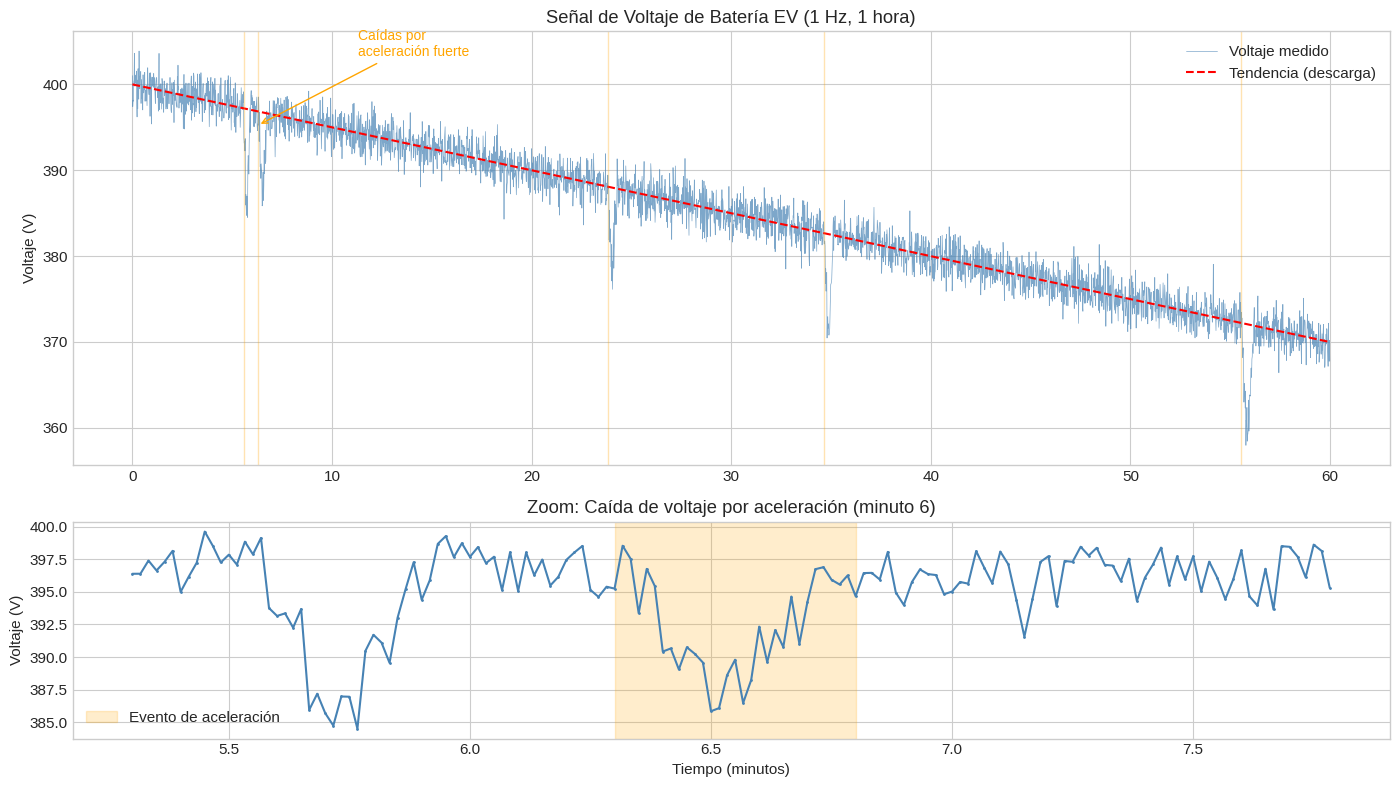

In [7]:
# Visualizar la señal de voltaje completa
tiempo_min = np.arange(n_puntos) / 60  # convertir a minutos

fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})

# Señal completa
axes[0].plot(tiempo_min, voltaje_final_signal, linewidth=0.5, color='steelblue', alpha=0.7, label='Voltaje medido')
axes[0].plot(tiempo_min, voltaje_base, color='red', linestyle='--', linewidth=1.5, label='Tendencia (descarga)')
for pos in posiciones_eventos:
    axes[0].axvline(pos / 60, color='orange', alpha=0.3, linewidth=1)
axes[0].set_ylabel('Voltaje (V)')
axes[0].set_title('Señal de Voltaje de Batería EV (1 Hz, 1 hora)')
axes[0].legend(loc='upper right')
axes[0].annotate('Caídas por\naceleración fuerte', xy=(posiciones_eventos[0]/60, voltaje_final_signal[posiciones_eventos[0]]),
                 xytext=(posiciones_eventos[0]/60 + 5, voltaje_final_signal[posiciones_eventos[0]] + 8),
                 arrowprops=dict(arrowstyle='->', color='orange'), fontsize=10, color='orange')

# Zoom en un evento
ev_pos = posiciones_eventos[0]
zoom_start = max(0, ev_pos - 60)
zoom_end = min(n_puntos, ev_pos + 90)
axes[1].plot(tiempo_min[zoom_start:zoom_end], voltaje_final_signal[zoom_start:zoom_end],
             linewidth=1.5, color='steelblue', marker='.', markersize=2)
axes[1].axvspan(ev_pos/60, (ev_pos+30)/60, alpha=0.2, color='orange', label='Evento de aceleración')
axes[1].set_xlabel('Tiempo (minutos)')
axes[1].set_ylabel('Voltaje (V)')
axes[1].set_title(f'Zoom: Caída de voltaje por aceleración (minuto {ev_pos//60})')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Ejercicio: Señal RPM del motor (10 Hz)

El RPM se muestrea a 10 Hz (10 valores por segundo), así que en 1 hora generamos 36,000 valores.
El RPM debe:
- Oscilar entre 800 (idle) y 6000 (alta potencia)
- Estar correlacionado con la velocidad
- Tener transiciones suaves

In [8]:
# RPM a 10 Hz
freq_rpm = 10
n_puntos_rpm = duracion_segundos * freq_rpm

# Perfil de velocidad a 1 Hz (random walk suavizado)
velocidad_1hz = np.zeros(duracion_segundos)
v = 0.0
for i in range(1, duracion_segundos):
    if rng.random() < 0.02:
        v = 0
    else:
        v += rng.normal(0.3, 1.5)
        v = np.clip(v, 0, 120)
    velocidad_1hz[i] = v

# Interpolar velocidad a 10 Hz
t_1hz = np.arange(duracion_segundos)
t_10hz = np.linspace(0, duracion_segundos - 1, n_puntos_rpm)
velocidad_10hz = np.interp(t_10hz, t_1hz, velocidad_1hz)

# RPM = f(velocidad) + ruido
rpm_idle = 800
rpm_factor = 40
rpm = velocidad_10hz * rpm_factor + rpm_idle + rng.normal(0, 50, n_puntos_rpm)
rpm = np.clip(rpm, 700, 6500)

print(f"RPM: {len(rpm):,} puntos (10 Hz × {duracion_segundos}s)")
print(f"  Media: {rpm.mean():.0f} RPM")
print(f"  Tamaño en memoria: {rpm.nbytes / 1024:.1f} KB")

RPM: 36,000 puntos (10 Hz × 3600s)
  Media: 1409 RPM
  Tamaño en memoria: 281.2 KB


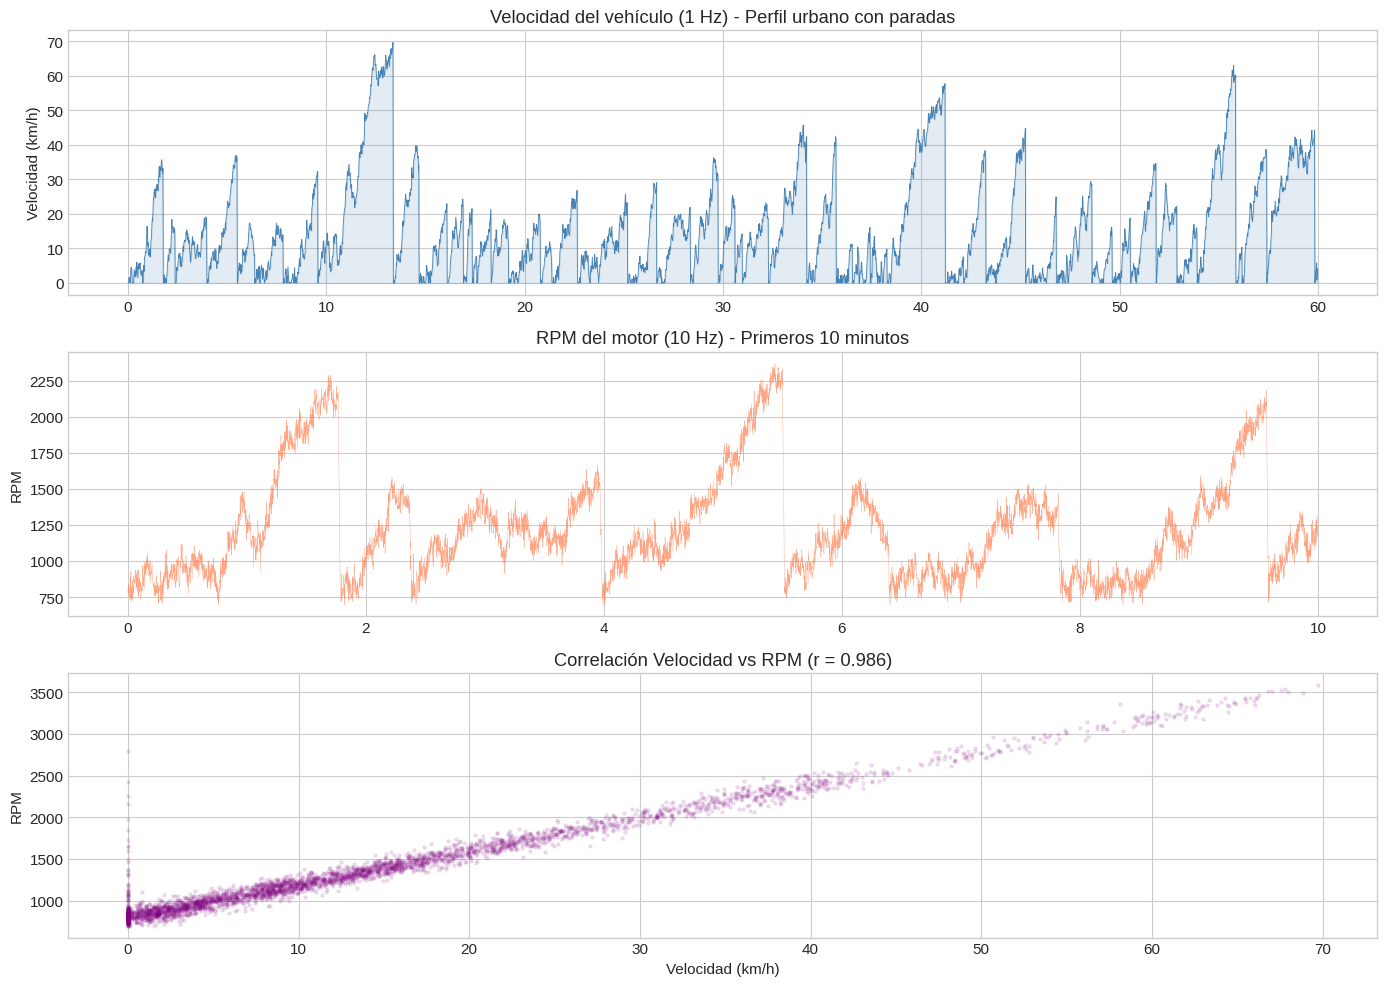

In [9]:
# Visualizar velocidad y RPM correlacionados
fig, axes = plt.subplots(3, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [1, 1, 1]})

# Velocidad (1 Hz)
axes[0].plot(t_1hz / 60, velocidad_1hz, linewidth=0.6, color='steelblue')
axes[0].set_ylabel('Velocidad (km/h)')
axes[0].set_title('Velocidad del vehículo (1 Hz) - Perfil urbano con paradas')
axes[0].fill_between(t_1hz / 60, velocidad_1hz, alpha=0.15, color='steelblue')

# RPM (10 Hz) - mostramos solo primeros 10 minutos para ver detalle
muestra_10min = 10 * 60 * freq_rpm  # 10 minutos en muestras a 10 Hz
axes[1].plot(t_10hz[:muestra_10min] / 60, rpm[:muestra_10min], linewidth=0.3, color='coral', alpha=0.7)
axes[1].set_ylabel('RPM')
axes[1].set_title('RPM del motor (10 Hz) - Primeros 10 minutos')

# Scatter: correlación velocidad-RPM
rpm_1hz = rpm[::freq_rpm]  # downsample a 1 Hz
min_len = min(len(velocidad_1hz), len(rpm_1hz))
scatter = axes[2].scatter(velocidad_1hz[:min_len], rpm_1hz[:min_len],
                          alpha=0.1, s=5, c='purple')
axes[2].set_xlabel('Velocidad (km/h)')
axes[2].set_ylabel('RPM')
corr = np.corrcoef(velocidad_1hz[:min_len], rpm_1hz[:min_len])[0, 1]
axes[2].set_title(f'Correlación Velocidad vs RPM (r = {corr:.3f})')

plt.tight_layout()
plt.show()

## 5. Impacto de la frecuencia de muestreo en el volumen de datos

**Pregunta de negocio clave:** ¿cuánto almacenamiento necesitamos según la frecuencia?

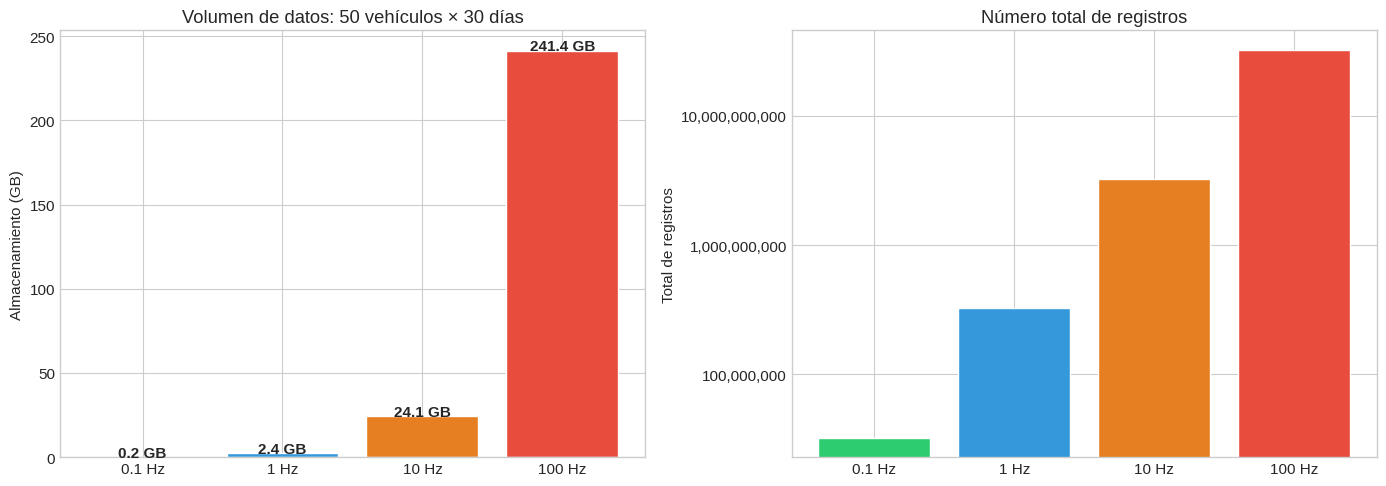


Conclusión: pasar de 1 Hz a 10 Hz multiplica el almacenamiento por 10x.
A 100 Hz necesitaríamos una base de datos especializada (TimescaleDB).


In [10]:
# Parámetros del escenario
n_vehiculos = 50
horas_por_dia = 4
dias = 30

sensores = {
    "battery_voltage": 1, "battery_current": 1, "battery_soc": 1,
    "battery_temp": 0.2, "motor_power": 10, "motor_rpm": 10,
    "speed": 1, "fuel_consumption": 1, "gps_lat": 1, "gps_lon": 1,
    "gps_heading": 1, "gps_altitude": 1,
    "accel_x": 10, "accel_y": 10, "accel_z": 10,
}
n_sensores = len(sensores)
bytes_por_valor = 8  # float64

# Calcular para diferentes frecuencias uniformes
frecuencias = [0.1, 1, 10, 100]
total_seconds = n_vehiculos * horas_por_dia * 3600 * dias

gb_por_freq = []
registros_por_freq = []
for freq in frecuencias:
    total_vals = n_sensores * freq * total_seconds
    total_bytes = total_vals * bytes_por_valor
    gb_por_freq.append(total_bytes / 1024**3)
    registros_por_freq.append(total_vals)

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']

# GB por frecuencia
bars1 = axes[0].bar([f'{f} Hz' for f in frecuencias], gb_por_freq, color=colors, edgecolor='white')
axes[0].set_ylabel('Almacenamiento (GB)')
axes[0].set_title(f'Volumen de datos: {n_vehiculos} vehículos × {dias} días')
for bar, gb in zip(bars1, gb_por_freq):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{gb:.1f} GB', ha='center', fontweight='bold')

# Registros (escala log)
bars2 = axes[1].bar([f'{f} Hz' for f in frecuencias], registros_por_freq, color=colors, edgecolor='white')
axes[1].set_ylabel('Total de registros')
axes[1].set_title('Número total de registros')
axes[1].set_yscale('log')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

print("\nConclusión: pasar de 1 Hz a 10 Hz multiplica el almacenamiento por 10x.")
print("A 100 Hz necesitaríamos una base de datos especializada (TimescaleDB).")

## 6. Operaciones con arrays: indexación, slicing, masking

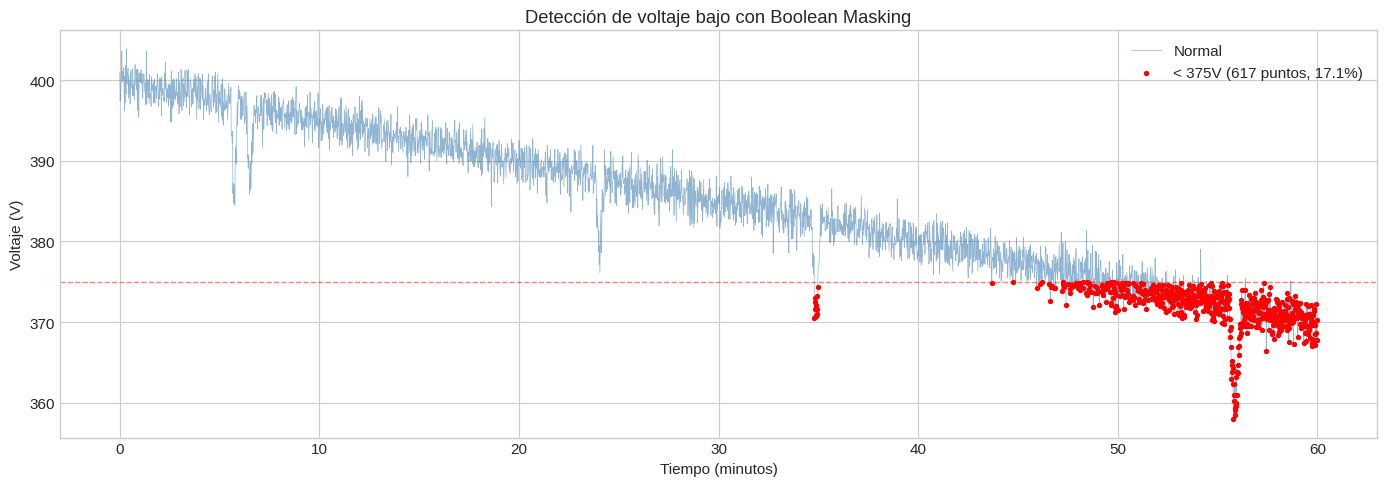

In [11]:
# Boolean masking: detectar voltaje bajo
mask_bajo = voltaje_final_signal < 375

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(tiempo_min, voltaje_final_signal, linewidth=0.5, color='steelblue', alpha=0.6, label='Normal')
ax.scatter(tiempo_min[mask_bajo], voltaje_final_signal[mask_bajo],
           color='red', s=8, zorder=5, label=f'< 375V ({mask_bajo.sum()} puntos, {mask_bajo.mean()*100:.1f}%)')
ax.axhline(375, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Tiempo (minutos)')
ax.set_ylabel('Voltaje (V)')
ax.set_title('Detección de voltaje bajo con Boolean Masking')
ax.legend()
plt.tight_layout()
plt.show()

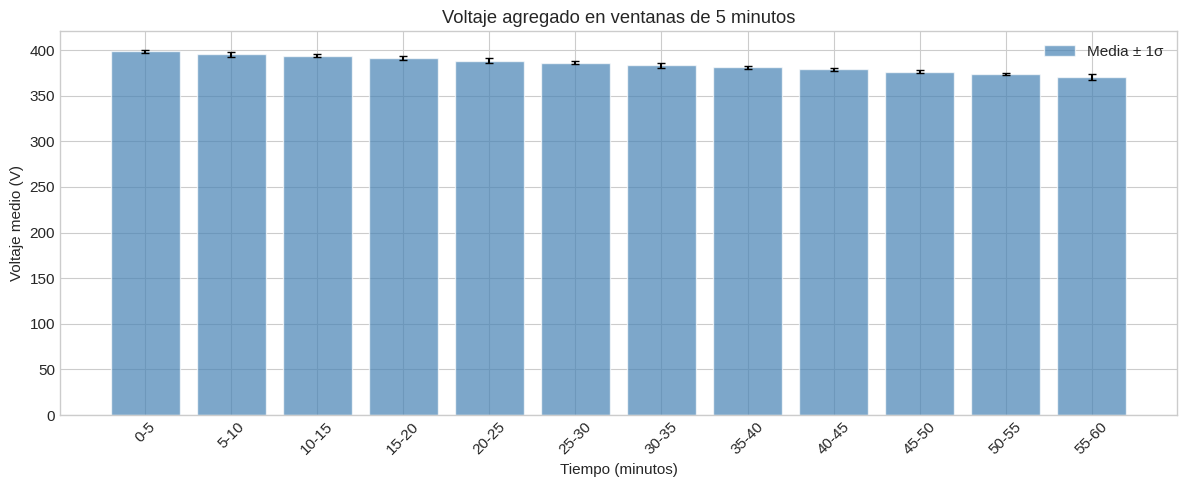

→ Se observa la tendencia descendente de la batería en cada ventana


In [12]:
# Reshaping: ventanas de 5 minutos
ventanas_5min = voltaje_final_signal.reshape(12, 300)
medias_ventana = ventanas_5min.mean(axis=1)
stds_ventana = ventanas_5min.std(axis=1)
minutos = np.arange(12) * 5 + 2.5  # centro de cada ventana

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(minutos, medias_ventana, width=4, color='steelblue', alpha=0.7, edgecolor='white',
       yerr=stds_ventana, capsize=3, label='Media ± 1σ')
ax.set_xlabel('Tiempo (minutos)')
ax.set_ylabel('Voltaje medio (V)')
ax.set_title('Voltaje agregado en ventanas de 5 minutos')
ax.set_xticks(minutos)
ax.set_xticklabels([f'{int(m-2.5)}-{int(m+2.5)}' for m in minutos], rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

print("→ Se observa la tendencia descendente de la batería en cada ventana")

## 7. Correlación entre señales

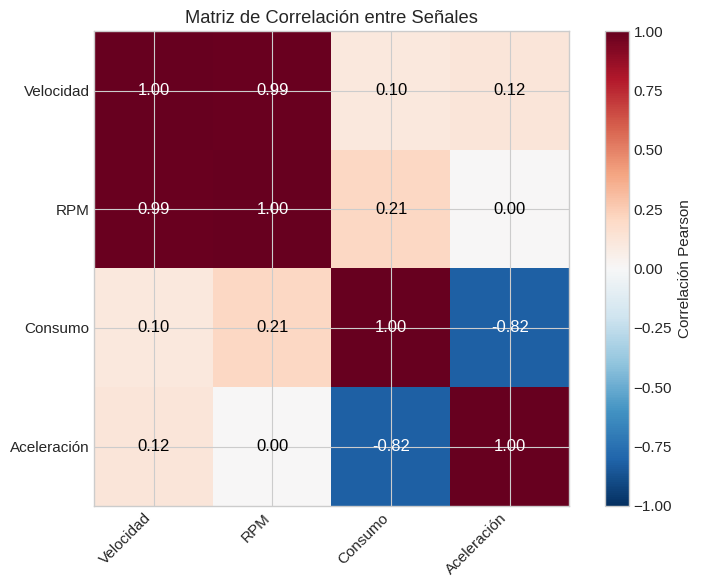

→ Velocidad y RPM tienen correlación alta (diseñado así)
→ Consumo correlaciona con velocidad (mayor velocidad = más gasto)


In [13]:
# Matriz de correlación visual
# Crear señales adicionales para la matriz
aceleracion = np.diff(velocidad_1hz, prepend=velocidad_1hz[0])
consumo_sim = velocidad_1hz * 0.08 + np.abs(aceleracion) * 2 + rng.normal(0, 0.3, duracion_segundos)
consumo_sim = np.maximum(consumo_sim, 0)

señales = np.column_stack([
    velocidad_1hz,
    rpm_1hz[:duracion_segundos],
    consumo_sim,
    aceleracion,
])
nombres = ['Velocidad', 'RPM', 'Consumo', 'Aceleración']
corr_matrix = np.corrcoef(señales.T)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(nombres)))
ax.set_yticks(range(len(nombres)))
ax.set_xticklabels(nombres, rotation=45, ha='right')
ax.set_yticklabels(nombres)
ax.set_title('Matriz de Correlación entre Señales')

# Anotar valores
for i in range(len(nombres)):
    for j in range(len(nombres)):
        color = 'white' if abs(corr_matrix[i, j]) > 0.5 else 'black'
        ax.text(j, i, f'{corr_matrix[i, j]:.2f}', ha='center', va='center', color=color, fontsize=12)

plt.colorbar(im, label='Correlación Pearson')
plt.tight_layout()
plt.show()

print("→ Velocidad y RPM tienen correlación alta (diseñado así)")
print("→ Consumo correlaciona con velocidad (mayor velocidad = más gasto)")

## Resumen y conclusiones

### Lo que aprendimos:
1. **Arrays NumPy** son la base de todo cálculo numérico en Python
2. Las **distribuciones aleatorias** (normal, uniforme, Poisson) modelan diferentes tipos de datos
3. La **frecuencia de muestreo** tiene un impacto enorme en el volumen: 10x frecuencia = 10x almacenamiento
4. Las **correlaciones entre señales** son clave para datos realistas

### Respuesta a la pregunta de negocio:
> **¿Cómo afecta la frecuencia de muestreo al volumen de datos?**
>
> El volumen crece linealmente con la frecuencia. Para 50 vehículos × 30 días,
> la diferencia puede ser entre MBs (1 Hz) y GBs (100 Hz). La decisión de frecuencia
> debe balancear resolución vs costo de infraestructura.

### Siguiente notebook:
→ `02_pandas_fundamentals.ipynb`: Organizar estos datos en DataFrames con índices temporales